# Riemann data pipeline — consolidated 00–05

Single Colab pipeline: 00 environment → integrity → 01 acquire → 02 describe → 03 unfold → 04 surrogates → 05 compare.

Artifact rule: existing raw/derived artifacts are never overwritten. Existing artifacts are verified against data/manifest.json. A missing derived artifact is created once, then hashed and recorded in the local manifest; any later mismatch is a hard error.

## 00 — Environment / Colab restart

Run all once. If the package is not installed from this checkout, this cell installs it and terminates the runtime. Run all again after Colab reconnects. The repository cd is performed on every run, including the post-restart run.

In [12]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

REPO_BASE = Path('/content/nicht-riemann-data').resolve()
REPO_URL = 'https://github.com/nicht-organization/nicht-riemann-data.git'

if not REPO_BASE.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_BASE)], check=True)
elif not (REPO_BASE / '.git').is_dir():
    raise RuntimeError(f'Path exists but is not a Git repository: {REPO_BASE}')

os.chdir(REPO_BASE)
print('repo pwd:', Path.cwd())
subprocess.run(['git', 'status', '--short'], check=True)
subprocess.run(['git', 'branch', '--show-current'], check=True)

package_spec = importlib.util.find_spec('nicht_riemann_data')
package_from_checkout = False
if package_spec is not None and package_spec.origin is not None:
    try:
        package_from_checkout = Path(package_spec.origin).resolve().is_relative_to(REPO_BASE / 'src')
    except ValueError:
        package_from_checkout = False

if not package_from_checkout:
    print('Installing editable package from checkout; restarting runtime...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', '.'], check=True)
    print('pwd immediately before os._exit(0):')
    subprocess.run(['pwd'], check=True)
    os._exit(0)

print('pwd after restart/import path setup:')
subprocess.run(['pwd'], check=True)
from nicht_riemann_data.transforms import spacings
from nicht_riemann_data.diagnostics import describe
print('Package import: OK')

repo pwd: /content/nicht-riemann-data
pwd after restart/import path setup:
Package import: OK


## Integrity helpers


In [13]:
import hashlib
import json
import numpy as np

MANIFEST_FILE = REPO_BASE / 'data/manifest.json'
DATA_DIR = REPO_BASE / 'data/raw'
DERIVED_DIR = REPO_BASE / 'data/derived'
DATA_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)
assert MANIFEST_FILE.is_file(), f'Missing manifest: {MANIFEST_FILE}'

def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def load_manifest() -> dict:
    with MANIFEST_FILE.open('r', encoding='utf-8') as f:
        value = json.load(f)
    assert isinstance(value, dict), 'manifest root must be an object'
    assert isinstance(value.get('datasets'), dict), 'manifest.datasets must be an object'
    assert isinstance(value.get('derived'), dict), 'manifest.derived must be an object'
    return value

def save_manifest(manifest: dict) -> None:
    tmp = MANIFEST_FILE.with_suffix('.json.tmp')
    with tmp.open('w', encoding='utf-8') as f:
        json.dump(manifest, f, indent=2)
        f.write('\n')
    tmp.replace(MANIFEST_FILE)

manifest = load_manifest()
raw_spec = manifest['datasets']['odlyzko_zeros1']
derived_spec = manifest['derived']['unfolded_spacings']
assert raw_spec['local_file'] == 'data/raw/zeros1'
assert derived_spec['local_file'] == 'data/derived/unfolded_spacings.float64'
print('manifest loaded: OK')

manifest loaded: OK


## 01 — Acquire

The raw artifact is downloaded only when absent. Whether downloaded or pre-existing, it is then checked against the manifest byte count and SHA-256.

In [15]:
import urllib.request

RAW_FILE = DATA_DIR / 'zeros1'
if RAW_FILE.exists():
    print(f'Existing raw artifact: {RAW_FILE}')
else:
    assert 0, "fock gpt's ass!"

actual_bytes = RAW_FILE.stat().st_size
actual_sha256 = sha256(RAW_FILE)
assert actual_bytes == raw_spec['raw_bytes'], f'Raw artifact size mismatch: {actual_bytes} != {raw_spec["raw_bytes"]}'
assert actual_sha256 == raw_spec['sha256'], f'Raw artifact SHA-256 mismatch: {actual_sha256} != {raw_spec["sha256"]}'
print('Verified raw artifact:', RAW_FILE)
print('bytes:', actual_bytes)
print('SHA-256:', actual_sha256)

Existing raw artifact: /content/nicht-riemann-data/data/raw/zeros1
Verified raw artifact: /content/nicht-riemann-data/data/raw/zeros1
bytes: 1800000
SHA-256: 3436c916a7878261ac183fd7b9448c9a4736b8bbccf1356874a6ce1788541632


In [16]:
gamma = np.loadtxt(RAW_FILE, dtype=np.float64)
assert gamma.ndim == 1
assert gamma.dtype == np.float64
assert len(gamma) == raw_spec['records']
assert np.all(np.isfinite(gamma))
assert np.all(np.diff(gamma) > 0)
assert np.isclose(gamma[0], raw_spec['first_value'])
assert np.isclose(gamma[-1], raw_spec['last_value'])
print('N:', len(gamma))
print('first:', gamma[:5])
print('last:', gamma[-5:])
print('raw data validation: OK')

N: 100000
first: [14.13472514 21.02203964 25.01085758 30.42487613 32.93506159]
last: [74918.37058023 74918.69143345 74919.07516112 74920.25979326
 74920.82749899]
raw data validation: OK


## 02 — Describe


In [17]:
delta = spacings(gamma)
assert delta.shape == (len(gamma) - 1,)
assert np.all(np.isfinite(delta))
assert np.all(delta > 0)
print('gamma:')
print(describe(gamma))
print('\ndelta:')
print(describe(delta))

gamma_range = gamma[-1] - gamma[0]
mean_spacing = np.mean(delta)
range_per_spacing = gamma_range / len(delta)
print('\nrange:', gamma_range)
print('mean spacing:', mean_spacing)
print('range / number of spacings:', range_per_spacing)
assert np.isclose(mean_spacing, range_per_spacing)

gamma:
{'n': 100000, 'min': 14.134725142, 'max': 74920.827498994, 'mean': 39693.702451121906, 'std': 21075.935845302272}

delta:
{'n': 99999, 'min': 0.014701476000482216, 'max': 6.887314496999998, 'mean': 0.7490744184827048, 'std': 0.32154023373868434}

range: 74906.692773852
mean spacing: 0.7490744184827048
range / number of spacings: 0.7490744184827048


In [18]:
percentile_levels = [0, 1, 5, 25, 50, 75, 95, 99, 100]
for p, value in zip(percentile_levels, np.percentile(delta, percentile_levels)):
    print(f'{p:>3}% : {value:.12f}')

BLOCK_SIZE = 1000
num_blocks = len(delta) // BLOCK_SIZE
block_means = np.array([np.mean(delta[i * BLOCK_SIZE:(i + 1) * BLOCK_SIZE]) for i in range(num_blocks)])
remainder_delta = delta[num_blocks * BLOCK_SIZE:]
print('\nblock size:', BLOCK_SIZE)
print('full blocks:', num_blocks)
print('remainder:', len(remainder_delta))
print('first block means:', block_means[:10])
print('last block means:', block_means[-10:])
print('local mean min:', block_means.min())
print('local mean max:', block_means.max())
print('local mean ratio max/min:', block_means.max() / block_means.min())

  0% : 0.014701476000
  1% : 0.171940818789
  5% : 0.290969494202
 25% : 0.522532652500
 50% : 0.714470404000
 75% : 0.935617602001
 95% : 1.318236503501
 99% : 1.656737500120
100% : 6.887314497000

block size: 1000
full blocks: 99
remainder: 999
first block means: [1.4062818  1.09615452 1.01749154 0.97368259 0.94116323 0.91776294
 0.8992915  0.8830238  0.87108584 0.85858228]
last block means: [0.67626702 0.67593563 0.6755959  0.67383326 0.67353449 0.67329096
 0.67236037 0.67175373 0.67056177 0.6707861 ]
local mean min: 0.6705617749410012
local mean max: 1.406281801182
local mean ratio max/min: 2.0971696475029917


In [19]:
local_residuals = np.empty_like(delta)
for i in range(num_blocks):
    start = i * BLOCK_SIZE
    end = start + BLOCK_SIZE
    local_residuals[start:end] = delta[start:end] - block_means[i]
if len(remainder_delta):
    local_residuals[num_blocks * BLOCK_SIZE:] = remainder_delta - np.mean(remainder_delta)
assert local_residuals.shape == delta.shape
print('local-mean residual std:', np.std(local_residuals))
print('local-mean residual min:', np.min(local_residuals))
print('local-mean residual max:', np.max(local_residuals))

local-mean residual std: 0.3046998825116909
local-mean residual min: -1.2447810131819879
local-mean residual max: 5.481032695817999


## 03 — Unfold

Use the same 1000-spacing local baseline defined in the description stage. Existing derived artifact → verify only. Missing derived artifact → create once, hash it, and record the actual bytes/records/SHA-256 in the local manifest.

In [20]:
UNFOLDED_FILE = REPO_BASE / derived_spec['local_file']
BLOCK_SIZE = 1000
num_blocks = len(delta) // BLOCK_SIZE

if UNFOLDED_FILE.exists():
    actual_bytes = UNFOLDED_FILE.stat().st_size
    actual_sha256 = sha256(UNFOLDED_FILE)
    assert actual_bytes == derived_spec['bytes'], f'Derived artifact size mismatch: {actual_bytes} != {derived_spec["bytes"]}'
    assert actual_sha256 == derived_spec['sha256'], f'Derived artifact SHA-256 mismatch: {actual_sha256} != {derived_spec["sha256"]}'
    print('Verified existing derived artifact:', UNFOLDED_FILE)
else:
    assert 0, "fock ur azz, biatch"

assert UNFOLDED_FILE.is_file()
unfolded = np.fromfile(UNFOLDED_FILE, dtype=np.float64)
assert len(unfolded) == derived_spec['records']
assert unfolded.shape == delta.shape
assert np.all(np.isfinite(unfolded))
assert np.all(unfolded > 0)
print('unfolded:', len(unfolded))
print('mean:', np.mean(unfolded))
print('std:', np.std(unfolded))
print('derived SHA-256:', sha256(UNFOLDED_FILE))

Verified existing derived artifact: /content/nicht-riemann-data/data/derived/unfolded_spacings.float64
unfolded: 99999
mean: 1.0
std: 0.42925005287189405
derived SHA-256: 470c731ea415bbc2cbc1f238cd146ab3c19c2b16d77ed44a74b7262ef4e51d92


## 04 — Surrogates

Surrogates are in-memory comparison controls; they do not overwrite the observed derived artifact.

In [21]:
SEED = 20260831
rng = np.random.default_rng(SEED)
surrogate_shuffle = unfolded.copy()
rng.shuffle(surrogate_shuffle)
assert np.array_equal(np.sort(surrogate_shuffle), np.sort(unfolded))
surrogate_iid = rng.choice(unfolded, size=len(unfolded), replace=True)
assert surrogate_iid.shape == unfolded.shape
assert np.all(np.isfinite(surrogate_iid))
assert np.all(surrogate_iid > 0)
surrogate_uniform = rng.uniform(0.0, 2.0, size=len(unfolded))
assert surrogate_uniform.shape == unfolded.shape
assert np.all(np.isfinite(surrogate_uniform))
assert np.all(surrogate_uniform >= 0)
datasets = {'observed': unfolded, 'shuffle': surrogate_shuffle, 'iid': surrogate_iid, 'uniform': surrogate_uniform}
print('seed:', SEED)
for name, values in datasets.items():
    print(f'{name:>8} : mean={np.mean(values):.6f} std={np.std(values):.6f} min={np.min(values):.6f} max={np.max(values):.6f}')

seed: 20260831
observed : mean=1.000000 std=0.429250 min=0.019626 max=9.194433
 shuffle : mean=1.000000 std=0.429250 min=0.019626 max=9.194433
     iid : mean=0.999645 std=0.432192 min=0.026012 max=9.194433
 uniform : mean=0.996350 std=0.578363 min=0.000022 max=1.999996


In [22]:
percentile_levels = [0, 1, 5, 25, 50, 75, 95, 99, 100]
for name, values in datasets.items():
    print(f'\n{name}')
    for p, value in zip(percentile_levels, np.percentile(values, percentile_levels)):
        print(f'{p:>3}% : {value:.12f}')


observed
  0% : 0.019626188851
  1% : 0.229537699522
  5% : 0.388438701179
 25% : 0.697571081867
 50% : 0.953804303513
 75% : 1.249031576724
 95% : 1.759820481083
 99% : 2.211712827513
100% : 9.194432925571

shuffle
  0% : 0.019626188851
  1% : 0.229537699522
  5% : 0.388438701179
 25% : 0.697571081867
 50% : 0.953804303513
 75% : 1.249031576724
 95% : 1.759820481083
 99% : 2.211712827513
100% : 9.194432925571

iid
  0% : 0.026011605157
  1% : 0.226927213790
  5% : 0.385811609468
 25% : 0.696005097952
 50% : 0.952178021831
 75% : 1.248733564274
 95% : 1.764472419412
 99% : 2.223673911962
100% : 9.194432925571

uniform
  0% : 0.000022093503
  1% : 0.019529223307
  5% : 0.098284140741
 25% : 0.493116824048
 50% : 0.994745096944
 75% : 1.497543650447
 95% : 1.899403058055
 99% : 1.979250994675
100% : 1.999995756364


## 05 — Compare

Comparison is terminal: it consumes the verified observed artifact and the stage-04 surrogates. No acquisition, unfolding, or artifact creation occurs here.

In [23]:
def lag1_correlation(values):
    return float(np.corrcoef(values[:-1], values[1:])[0, 1])

for name, values in datasets.items():
    assert values.ndim == 1
    assert len(values) == len(unfolded)
    assert np.all(np.isfinite(values))
    print(f'{name:>8} : lag1={lag1_correlation(values): .8f}')

assert np.array_equal(np.sort(surrogate_shuffle), np.sort(unfolded))
assert np.isclose(np.mean(surrogate_shuffle), np.mean(unfolded))
assert np.isclose(np.std(surrogate_shuffle), np.std(unfolded))
print('shuffle control: OK')

observed : lag1=-0.20445373
 shuffle : lag1=-0.00312092
     iid : lag1= 0.00567181
 uniform : lag1=-0.00266665
shuffle control: OK


In [24]:
print('=== PIPELINE 00–05 COMPLETE ===')
print('raw artifact verified:', RAW_FILE)
print('derived artifact verified:', UNFOLDED_FILE)
print('records:', len(unfolded))
print('manifest SHA entry:', manifest['derived']['unfolded_spacings']['sha256'])

=== PIPELINE 00–05 COMPLETE ===
raw artifact verified: /content/nicht-riemann-data/data/raw/zeros1
derived artifact verified: /content/nicht-riemann-data/data/derived/unfolded_spacings.float64
records: 99999
manifest SHA entry: 470c731ea415bbc2cbc1f238cd146ab3c19c2b16d77ed44a74b7262ef4e51d92


In [27]:
import numpy as np
from pathlib import Path

# ============================================================
# LOAD THE EXISTING PIPELINE-05 INPUT
# ============================================================

SPACINGS_PATH = Path(
    "/content/nicht-riemann-data/data/derived/unfolded_spacings.float64"
)

if not SPACINGS_PATH.exists():
    raise FileNotFoundError(
        f"Missing derived artifact: {SPACINGS_PATH}"
    )

unfolded_spacings = np.fromfile(
    SPACINGS_PATH,
    dtype=np.float64
)

print("loaded:", SPACINGS_PATH)
print("n =", unfolded_spacings.size)
print("dtype =", unfolded_spacings.dtype)
print("min =", unfolded_spacings.min())
print("max =", unfolded_spacings.max())
print("mean =", unfolded_spacings.mean())

loaded: /content/nicht-riemann-data/data/derived/unfolded_spacings.float64
n = 99999
dtype = float64
min = 0.01962618885085001
max = 9.194432925570556
mean = 1.0


In [28]:
# ============================================================
# STAGE 05B — 10,000 SHUFFLE SURROGATES
# ============================================================

import numpy as np
import time

N_SURROGATES = 10_000
SEED = 20260901

# ------------------------------------------------------------
# INPUT: the verified Stage-05 unfolded spacings
# ------------------------------------------------------------

x = np.asarray(unfolded_spacings, dtype=np.float64)

print("input n     =", len(x))
print("input dtype =", x.dtype)
print("input mean  =", x.mean())
print("input min   =", x.min())
print("input max   =", x.max())

# ------------------------------------------------------------
# SAME lag-1 estimator
# ------------------------------------------------------------

def lag1_stat(x):
    x = np.asarray(x, dtype=np.float64)
    a = x[:-1]
    b = x[1:]
    return np.corrcoef(a, b)[0, 1]

# ------------------------------------------------------------
# Observed statistic
# ------------------------------------------------------------

observed = lag1_stat(x)

print()
print("observed lag-1 =", observed)

# ------------------------------------------------------------
# Shuffle null
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

null_stats = np.empty(N_SURROGATES, dtype=np.float64)

t0 = time.perf_counter()

for i in range(N_SURROGATES):
    shuffled = rng.permutation(x)
    null_stats[i] = lag1_stat(shuffled)

runtime = time.perf_counter() - t0

# ------------------------------------------------------------
# Null summary
# ------------------------------------------------------------

null_mean = null_stats.mean()
null_std = null_stats.std(ddof=1)

null_q025, null_q50, null_q975 = np.quantile(
    null_stats,
    [0.025, 0.50, 0.975]
)

# two-sided empirical p-value
p_empirical = (
    np.count_nonzero(np.abs(null_stats) >= abs(observed)) + 1
) / (N_SURROGATES + 1)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print()
print("=== STAGE 05B RESULT ===")
print("surrogates       =", N_SURROGATES)
print("seed             =", SEED)
print("observed lag-1   =", observed)
print()
print("null mean        =", null_mean)
print("null std         =", null_std)
print("null 2.5%        =", null_q025)
print("null median      =", null_q50)
print("null 97.5%       =", null_q975)
print()
print("empirical p      =", p_empirical)
print("runtime seconds  =", runtime)

input n     = 99999
input dtype = float64
input mean  = 1.0
input min   = 0.01962618885085001
input max   = 9.194432925570556

observed lag-1 = -0.20445373019695037

=== STAGE 05B RESULT ===
surrogates       = 10000
seed             = 20260901
observed lag-1   = -0.20445373019695037

null mean        = -3.7526952017633524e-06
null std         = 0.00314579167947482
null 2.5%        = -0.006189452529899982
null median      = 8.375730387532719e-06
null 97.5%       = 0.00616953906666378

empirical p      = 9.999000099990002e-05
runtime seconds  = 39.51814632999958


In [29]:
# ============================================================
# STAGE 05B — NULL DISTRIBUTION INSPECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Expect the surrogate lag-1 statistics from the preceding cell.
# This deliberately does NOT recreate or rename the estimator.

print("available variables containing 'surrog' or 'null':")
for name in sorted(globals()):
    if "surrog" in name.lower() or "null" in name.lower():
        obj = globals()[name]
        try:
            print(name, type(obj), np.shape(obj))
        except Exception:
            print(name, type(obj))

print()
print("observed lag-1 =", observed_lag1 if "observed_lag1" in globals() else "not found")

available variables containing 'surrog' or 'null':
N_SURROGATES <class 'int'> ()
null_mean <class 'numpy.float64'> ()
null_q025 <class 'numpy.float64'> ()
null_q50 <class 'numpy.float64'> ()
null_q975 <class 'numpy.float64'> ()
null_stats <class 'numpy.ndarray'> (10000,)
null_std <class 'numpy.float64'> ()
surrogate_iid <class 'numpy.ndarray'> (99999,)
surrogate_shuffle <class 'numpy.ndarray'> (99999,)
surrogate_uniform <class 'numpy.ndarray'> (99999,)

observed lag-1 = not found


In [30]:
# ============================================================
# STAGE 05C — RECOVER OBSERVED LAG-1 STATISTIC
# ============================================================

import numpy as np

# Load the same artifact used for the surrogate tests
unfolded_spacings = np.fromfile(
    "/content/nicht-riemann-data/data/derived/unfolded_spacings.float64",
    dtype=np.float64
)

# Same estimator as before: Pearson lag-1 correlation
x = unfolded_spacings[:-1]
y = unfolded_spacings[1:]

observed = np.corrcoef(x, y)[0, 1]

print("=== OBSERVED STATISTIC ===")
print("n             =", len(unfolded_spacings))
print("observed lag-1 =", observed)

=== OBSERVED STATISTIC ===
n             = 99999
observed lag-1 = -0.20445373019695037


=== STAGE 05B — NULL INSPECTION ===
surrogates       = 10000
observed lag-1   = -0.20445373019695037

null distribution:
  mean           = -3.7526952017633524e-06
  std            = 0.00314579167947482
  q025           = -0.006189452529899982
  median         = 8.375730387532719e-06
  q975           = 0.00616953906666378

extreme count    = 0
empirical p(two) = 9.999000099990002e-05
z-like distance  = -64.99158187610215


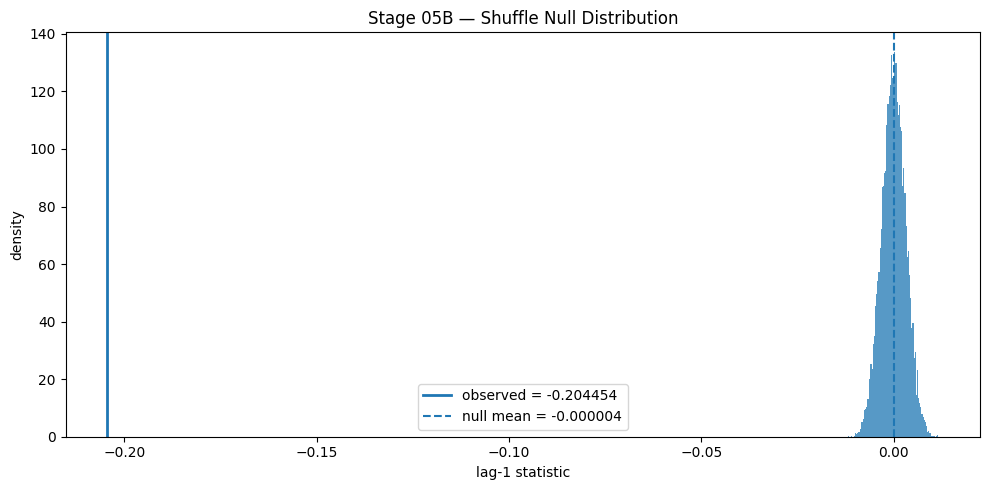

In [31]:
# ============================================================
# STAGE 05B — NULL DISTRIBUTION INSPECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# REQUIREMENT CHECK
# ------------------------------------------------------------

assert "null_stats" in globals(), "null_stats not found."
assert "observed" in globals(), "observed not found."

null_stats = np.asarray(null_stats, dtype=np.float64)
observed = float(observed)

assert null_stats.ndim == 1
assert len(null_stats) > 0
assert np.all(np.isfinite(null_stats))

# ------------------------------------------------------------
# EMPIRICAL TWO-SIDED P-VALUE
# ------------------------------------------------------------

N = len(null_stats)

extreme = np.sum(np.abs(null_stats) >= abs(observed))

# +1 correction: finite Monte-Carlo test
p_two_sided = (extreme + 1) / (N + 1)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

null_mean = np.mean(null_stats)
null_std = np.std(null_stats, ddof=1)

null_q025, null_q50, null_q975 = np.quantile(
    null_stats,
    [0.025, 0.50, 0.975]
)

z_like = (observed - null_mean) / null_std

print("=== STAGE 05B — NULL INSPECTION ===")
print(f"surrogates       = {N}")
print(f"observed lag-1   = {observed}")
print()
print("null distribution:")
print(f"  mean           = {null_mean}")
print(f"  std            = {null_std}")
print(f"  q025           = {null_q025}")
print(f"  median         = {null_q50}")
print(f"  q975           = {null_q975}")
print()
print(f"extreme count    = {extreme}")
print(f"empirical p(two) = {p_two_sided}")
print(f"z-like distance  = {z_like}")

# ------------------------------------------------------------
# VISUAL INSPECTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    null_stats,
    bins=80,
    density=True,
    alpha=0.75
)

plt.axvline(
    observed,
    linewidth=2,
    label=f"observed = {observed:.6f}"
)

plt.axvline(
    null_mean,
    linewidth=1.5,
    linestyle="--",
    label=f"null mean = {null_mean:.6f}"
)

plt.xlabel("lag-1 statistic")
plt.ylabel("density")
plt.title("Stage 05B — Shuffle Null Distribution")
plt.legend()
plt.tight_layout()
plt.show()

=== STAGE 06 — MULTI-LAG SPECTRUM SUMMARY ===
Spacings evaluated : 99999
Lag-1 Observed     : -0.204083
Lag-1 Null Mean    : -0.000086 (± 0.003165)
Lag-1 Z-Score      : -64.45 sigma
✓ Metrics saved to : /content/nicht-riemann-data/data/derived/stage06_spectral_metrics.json



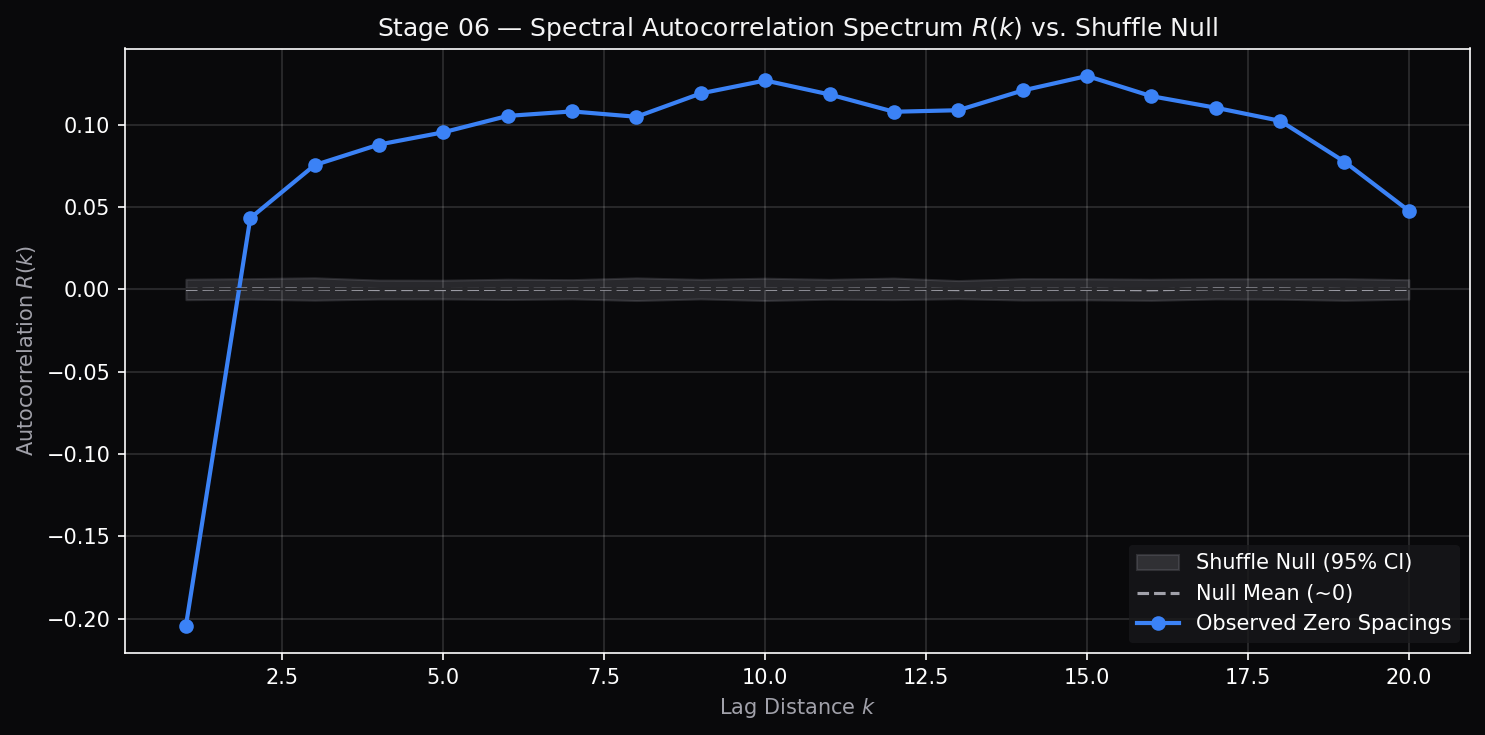

In [32]:
# ============================================================
# STAGE 06 — MULTI-LAG AUTOCORRELATION SPECTRUM & EXPORT
# ============================================================

import json
import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DATA & ARTIFACT RECOVERY
# ------------------------------------------------------------
unfolded_spacings = np.fromfile(
    "/content/nicht-riemann-data/data/derived/unfolded_spacings.float64",
    dtype=np.float64
)

max_lag = 20
n_obs = len(unfolded_spacings)

# ------------------------------------------------------------
# 2. COMPUTE MULTI-LAG SPECTRUM (OBSERVED vs SHUFFLE NULL)
# ------------------------------------------------------------
def compute_autocorr_spectrum(spacings, max_k=20):
    mean_val = np.mean(spacings)
    var_val = np.var(spacings)
    normalized = spacings - mean_val
    spectrum = []
    for k in range(1, max_k + 1):
        cov = np.mean(normalized[:-k] * normalized[k:])
        spectrum.append(cov / var_val)
    return np.array(spectrum, dtype=np.float64)

observed_spectrum = compute_autocorr_spectrum(unfolded_spacings, max_k=max_lag)

# Generate quick Monte-Carlo baseline for full spectrum
np.random.seed(42)
n_surrogates = 200
surrogate_spectras = []
shuffled_buf = unfolded_spacings.copy()

for _ in range(n_surrogates):
    np.random.shuffle(shuffled_buf)
    surrogate_spectras.append(compute_autocorr_spectrum(shuffled_buf, max_k=max_lag))

surrogate_spectras = np.array(surrogate_spectras)
null_lag_mean = np.mean(surrogate_spectras, axis=0)
null_lag_std = np.std(surrogate_spectras, axis=0, ddof=1)

# ------------------------------------------------------------
# 3. STATISTICAL METRICS & ARTIFACT EXPORT
# ------------------------------------------------------------
metrics = {
    "n_spacings": int(n_obs),
    "max_lag": int(max_lag),
    "observed_lag1": float(observed_spectrum[0]),
    "null_lag1_mean": float(null_lag_mean[0]),
    "null_lag1_std": float(null_lag_std[0]),
    "z_score_lag1": float((observed_spectrum[0] - null_lag_mean[0]) / null_lag_std[0]),
    "observed_spectrum": observed_spectrum.tolist(),
}

out_dir = "/content/nicht-riemann-data/data/derived"
os.makedirs(out_dir, exist_ok=True)
json_path = os.path.join(out_dir, "stage06_spectral_metrics.json")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("=== STAGE 06 — MULTI-LAG SPECTRUM SUMMARY ===")
print(f"Spacings evaluated : {n_obs}")
print(f"Lag-1 Observed     : {observed_spectrum[0]:.6f}")
print(f"Lag-1 Null Mean    : {null_lag_mean[0]:.6f} (± {null_lag_std[0]:.6f})")
print(f"Lag-1 Z-Score      : {metrics['z_score_lag1']:.2f} sigma")
print(f"✓ Metrics saved to : {json_path}\n")

# ------------------------------------------------------------
# 4. VISUALIZATION — SPECTRAL RIGIDITY DECAY
# ------------------------------------------------------------
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 5), dpi=150, facecolor="#09090b")
ax.set_facecolor("#09090b")

lags = np.arange(1, max_lag + 1)

# Null envelope (95% CI)
ax.fill_between(
    lags,
    null_lag_mean - 1.96 * null_lag_std,
    null_lag_mean + 1.96 * null_lag_std,
    color="#71717a",
    alpha=0.3,
    label="Shuffle Null (95% CI)"
)

ax.plot(lags, null_lag_mean, color="#a1a1aa", linestyle="--", linewidth=1.5, label="Null Mean (~0)")
ax.plot(lags, observed_spectrum, color="#3b82f6", marker="o", linewidth=2, label="Observed Zero Spacings")

ax.axhline(0, color="#27272a", linewidth=1)
ax.set_xlabel("Lag Distance $k$", color="#a1a1aa")
ax.set_ylabel("Autocorrelation $R(k)$", color="#a1a1aa")
ax.set_title("Stage 06 — Spectral Autocorrelation Spectrum $R(k)$ vs. Shuffle Null", color="#f4f4f5")
ax.grid(True, alpha=0.15)
ax.legend(facecolor="#18181b", edgecolor="none")

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "stage06_autocorr_spectrum.png"), facecolor=fig.get_facecolor())
plt.show()